In [ ]:
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder
import torch
from torch import nn
import torch.functional as F
from torch.utils.data import DataLoader, Subset, random_split

from torchvision.transforms import InterpolationMode
from torchvision import models
from torchvision.datasets import VisionDataset
from torchvision.transforms import ToTensor, Resize, Normalize, Compose, RandomResizedCrop, ColorJitter, RandomHorizontalFlip, RandomPerspective, RandomRotation, InterpolationMode, RandomApply, GaussianBlur

import random
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, KFold

from PIL import Image

from tqdm import tqdm
import re
import json

import os
import requests

import warnings
warnings.filterwarnings("ignore")

root_dir = "data"
img_dir = "images"
csv_path = "good_atomic_no_noise_polished.csv"

### Инициализация

In [ ]:
def get_idx_row_from_image(img_name, data):
    (id, img_num) = img_name.split(".")[0].split("_")
    id = int(id)
    img_num = int(img_num)
    series = data[(data["ID"] == id) & (data["img_num"] == img_num)]
    idx = series.index[0]
    row = series.iloc[0]

    return (idx, row)

class Attr(VisionDataset):
    def __init__(self, root_dir, img_dir, csv_path, transform=None):
        self.root_dir = root_dir
        self.img_dir = img_dir
        self.csv_path = csv_path

        super().__init__(self.root_dir, transform=transform)

        self.transform = transform

        self.image_paths = []
        self.labels = []
        self.orig_indices = []

        self._build_dataset()

    def _build_dataset(self):
        data = pd.read_csv(os.path.join(self.root_dir, self.csv_path))
        for img_name in os.listdir(os.path.join(self.root_dir, self.img_dir)):
            #idx = int(img_name.split('.')[0]) // old

            try:
                idx, row = get_idx_row_from_image(img_name, data)
            except:
                continue


            self.labels.append(row.attr_ind)
            self.orig_indices.append(idx)

            img_path = os.path.join(self.root_dir, self.img_dir, img_name)
            self.image_paths.append(img_path)

        print(f"Dataset loaded: {len(self.image_paths)} images")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

train_transform = Compose([
    RandomResizedCrop(
        size=(384, 384),
        scale=(0.7, 1.0),
        ratio=(0.9, 1.1)
    ),
    RandomHorizontalFlip(p=0.5),

    ColorJitter(
        brightness=0.2,
        contrast=0.3,
        saturation=0.15,
        hue=0.05
    ),

    RandomApply([
        GaussianBlur(kernel_size=3, sigma=(0.1, 0.7))
    ], p=0.2),

    RandomApply([
        RandomRotation(
            degrees=7,
            interpolation=InterpolationMode.BICUBIC
        )
    ], p=0.3),

    RandomApply([
        RandomPerspective(
            distortion_scale=0.15,
            p=1.0
        )
    ], p=0.2),

    ToTensor(),

    Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

default_transform = Compose([
    Resize((384, 384)),
    ToTensor(),
    Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

def binary_accuracy(t, p):
    return ((p[np.where(t == 0)] == 0).sum() + (p[np.where(t != 0)] != 0).sum()) / len(t)

def light_accuracy(t, p, exclude_confusion: list[list]):
    correct = (p == t).sum()

    for labels in exclude_confusion:
        ind = np.where(np.isin(t, labels))
        correct += (np.isin(p[ind], labels) & (p[ind] != t[ind])).sum()

    return correct / len(t)

def accuracy_when_confident(t, probs, confidence_level):
    where_confident = np.where((probs > confidence_level))
    p_where_confident = where_confident[1]
    t_where_confident = t[where_confident[0]]

    return accuracy_score(t_where_confident, p_where_confident)

def train_model(model, train_loader, val_loader, epochs, lr, do_val, weights=None):
    criterion = nn.CrossEntropyLoss()
    if weights is not None:
        criterion.weight = weights

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01, betas=(0.9, 0.999))

    history = {"train_loss": []}
    if do_val:
        history["val_acc"] = []
        history["val_acc_binary"] = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        print("Training:")
        for x, y in tqdm(train_loader):
            x = x.to(device)
            y = y.to(device).long()

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_loss = train_loss / len(train_loader)
        history["train_loss"].append(avg_loss)

        print(f"Epoch {epoch+1}/{epochs}:")
        print(f"  Train loss: {avg_loss:.4f}")

        if not do_val:
            continue

        model.eval()
        all_probs = []
        all_preds = []
        all_y = []

        print("Validation:")
        with torch.no_grad():
            for x, y in tqdm(val_loader):
                x = x.to(device)
                y = y.to(device).long()

                out = model(x)
                probs = torch.softmax(out, dim=1)
                preds = torch.argmax(probs, dim=1)

                all_probs.append(probs.cpu())
                all_preds.append(preds.cpu())
                all_y.append(y.cpu())

        all_probs = torch.cat(all_probs).numpy()
        all_preds = torch.cat(all_preds).numpy()
        all_y = torch.cat(all_y).numpy()

        val_acc = accuracy_score(all_y, all_preds)
        val_acc_binary = binary_accuracy(all_y, all_preds)
        val_acc_light = light_accuracy(all_y, all_preds, [[5, 6], [5, 7]])
        val_acc_confidence_90 = accuracy_when_confident(all_y, all_probs, 0.9)
        val_acc_confidence_95 = accuracy_when_confident(all_y, all_probs, 0.95)
        val_acc_confidence_99 = accuracy_when_confident(all_y, all_probs, 0.99)

        print()
        print(f"  Val accuracy: {val_acc:.4f}")
        print(f"  Val accuracy for 0 vs rest: {val_acc_binary:.4f}")
        print(f"  Val accuracy excluding 5=6 and 5=7 confusion: {val_acc_light:.4f}")
        print(f"  Val accuracy when 90% confident: {val_acc_confidence_90:.4f}")
        print(f"  Val accuracy when 95% confident: {val_acc_confidence_95:.4f}")
        print(f"  Val accuracy when 99% confident: {val_acc_confidence_99:.4f}")

        history["val_acc"].append(val_acc)
        history["val_acc_binary"].append(val_acc_binary)

    return history

### KFold

In [ ]:
ds = Attr(transform=default_transform, root_dir=root_dir, img_dir=img_dir, csv_path=csv_path)

device = "cuda" if torch.cuda.is_available() else "cpu"

splits = 5
kfold = KFold(n_splits=splits, shuffle=True, random_state=42)

Dataset loaded: 13931 images


#### Swin S

In [ ]:
swin_history = {}

for fold, (train_idx, test_idx) in enumerate(kfold.split(ds)):
    print(f"==================================== Fold {fold + 1} ====================================")

    train_ds = Subset(ds, train_idx)
    train_ds.transform = train_transform
    test_ds = Subset(ds, test_idx)

    model = models.swin_s(weights="Swin_S_Weights.DEFAULT")
    for p in model.parameters():
        p.requires_grad = False
    model.head = nn.Linear(model.head.in_features, 9, bias=True)
    model.to(device)

    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
    hist = {}

    print("\nTraining head\n")
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    hist["head"] = train_model(model, train_loader=train_loader, val_loader=test_loader, epochs=3, lr=0.001, do_val=True)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

    print("\n\nUnfreezing more layers\n")
    for p in model.norm.parameters():
        p.requires_grad = True
    for p in model.features[6].parameters():
        p.requires_grad = True
    for p in model.features[7].parameters():
        p.requires_grad = True
    hist["unfreeze_1"] = train_model(model, train_loader=train_loader, val_loader=test_loader, epochs=1, lr=0.0005, do_val=True)

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

    print("\n\nUnfreezing more layers\n")
    for p in model.features[5][12:].parameters():
        p.requires_grad = True
    hist["unfreeze_2"] = train_model(model, train_loader=train_loader, val_loader=test_loader, epochs=2, lr=0.0001, do_val=True)

    print("\n\nUnfreezing more layers\n")
    for p in model.features[5][4:].parameters():
        p.requires_grad = True
    hist["unfreeze_3"] = train_model(model, train_loader=train_loader, val_loader=test_loader, epochs=1, lr=0.00005, do_val=True)

    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)

    print("\n\nUnfreezing remaining layers\n")
    for p in model.parameters():
        p.requires_grad = True
    hist["unfreeze_all"] = train_model(model, train_loader=train_loader, val_loader=test_loader, epochs=1, lr=0.00001, do_val=True)

    torch.save(model.state_dict(), f"models/KFold/swin_s_atomic_fold{fold + 1}")

    swin_history[f"fold_{fold + 1}"] = hist

with open("proof/swin_s.json", "w") as f:
    json.dump(swin_history, f, indent=4)

==================================== Fold 1 ====================================

Training head

Training:


100%|████████████████████████████████████████████████████████████████████████████████| 175/175 [03:33<00:00,  1.22s/it]


Epoch 1/3:
  Train loss: 1.2691
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:53<00:00,  1.21s/it]



  Val accuracy: 0.5849
  Val accuracy for 0 vs rest: 0.7079
  Val accuracy excluding 5=6 and 5=7 confusion: 0.6491
  Val accuracy when 90% confident: 0.9625
  Val accuracy when 95% confident: 1.0000
  Val accuracy when 99% confident: nan
Training:


...


  Val accuracy: 0.7383
  Val accuracy for 0 vs rest: 0.8439
  Val accuracy excluding 5=6 and 5=7 confusion: 0.7976
  Val accuracy when 90% confident: 0.8951
  Val accuracy when 95% confident: 0.9169
  Val accuracy when 99% confident: 0.9585


Unfreezing remaining layers

Training:


100%|██████████████████████████████████████████████████████████████████████████████| 1394/1394 [06:07<00:00,  3.79it/s]


Epoch 1/1:
  Train loss: 0.3108
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:53<00:00,  1.21s/it]


  Val accuracy: 0.7430
  Val accuracy for 0 vs rest: 0.8460
  Val accuracy excluding 5=6 and 5=7 confusion: 0.8022
  Val accuracy when 90% confident: 0.8827
  Val accuracy when 95% confident: 0.9102
  Val accuracy when 99% confident: 0.9526


#### ConvNeXt S

In [ ]:
convnext_history = {}

for fold, (train_idx, test_idx) in enumerate(kfold.split(ds)):
    print(f"==================================== Fold {fold + 1} ====================================")

    train_ds = Subset(ds, train_idx)
    train_ds.transform = train_transform
    test_ds = Subset(ds, test_idx)

    model = models.convnext_small(weights="ConvNeXt_Small_Weights.DEFAULT")

    for p in model.parameters():
        p.requires_grad = False

    model.classifier[2] = nn.Linear(model.classifier[2].in_features, 9, bias=True)
    model.to(device)

    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
    hist = {}

    print("\nTraining head\n")
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    hist["head"] = train_model(model, train_loader=train_loader, val_loader=test_loader, epochs=3, lr=0.001, do_val=True)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

    print("\n\nUnfreezing more layers\n")
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

    for p in model.features[7].parameters():
        p.requires_grad = True
    for p in model.features[6].parameters():
        p.requires_grad = True
    hist["unfreeze_1"] = train_model(model, train_loader=train_loader, val_loader=test_loader, epochs=1, lr=0.0007, do_val=True)

    print("\n\nUnfreezing more layers\n")
    for p in model.features[5][20:].parameters():
        p.requires_grad = True
    hist["unfreeze_2"] = train_model(model, train_loader=train_loader, val_loader=test_loader, epochs=1, lr=0.0005, do_val=True)

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

    print("\n\nUnfreezing more layers\n")
    for p in model.features[5][10:].parameters():
        p.requires_grad = True
    hist["unfreeze_3"] = train_model(model, train_loader=train_loader, val_loader=test_loader, epochs=1, lr=0.0001, do_val=True)

    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)

    print("\n\nUnfreezing more layers\n")
    for p in model.features[5].parameters():
        p.requires_grad = True
    hist["unfreeze_4"] = train_model(model, train_loader=train_loader, val_loader=test_loader, epochs=1, lr=0.00005, do_val=True)

    print("\n\nUnfreezing remaining layers\n")
    for p in model.parameters():
        p.requires_grad = True
    hist["unfreeze_all"] = train_model(model, train_loader=train_loader, val_loader=test_loader, epochs=1, lr=0.00001, do_val=True)

    torch.save(model.state_dict(), f"models/KFold/convnext_s_atomic_fold{fold + 1}")

    convnext_history[f"fold_{fold + 1}"] = hist

with open("proof/convnext_s.json", "w") as f:
    json.dump(convnext_history, f, indent=4)


==================================== Fold 1 ====================================

Training head

Training:


100%|████████████████████████████████████████████████████████████████████████████████| 175/175 [03:05<00:00,  1.06s/it]


Epoch 1/3:
  Train loss: 1.2619
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:45<00:00,  1.04s/it]



  Val accuracy: 0.5813
  Val accuracy for 0 vs rest: 0.7058
  Val accuracy excluding 5=6 and 5=7 confusion: 0.6516
  Val accuracy when 90% confident: 0.9282
  Val accuracy when 95% confident: 0.9697
  Val accuracy when 99% confident: nan
Training:


...


  Val accuracy: 0.7057
  Val accuracy for 0 vs rest: 0.8195
  Val accuracy excluding 5=6 and 5=7 confusion: 0.7685
  Val accuracy when 90% confident: 0.8746
  Val accuracy when 95% confident: 0.9022
  Val accuracy when 99% confident: 0.9406


Unfreezing remaining layers

Training:


100%|██████████████████████████████████████████████████████████████████████████████| 1394/1394 [07:24<00:00,  3.14it/s]


Epoch 1/1:
  Train loss: 0.2211
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:48<00:00,  1.09s/it]


  Val accuracy: 0.7459
  Val accuracy for 0 vs rest: 0.8406
  Val accuracy excluding 5=6 and 5=7 confusion: 0.8015
  Val accuracy when 90% confident: 0.8656
  Val accuracy when 95% confident: 0.8939
  Val accuracy when 99% confident: 0.9489


#### ResNet

In [ ]:
resnet_history = {}

for fold, (train_idx, test_idx) in enumerate(kfold.split(ds)):
    print(f"==================================== Fold {fold + 1} ====================================")

    train_ds = Subset(ds, train_idx)
    train_ds.transform = train_transform
    test_ds = Subset(ds, test_idx)

    model = models.resnet50(weights="ResNet50_Weights.DEFAULT")
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, 9, bias=True)
    model.to(device)

    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
    hist = {}

    print("\nTraining head\n")
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    hist["head"] = train_model(model, train_loader=train_loader, val_loader=test_loader, epochs=3, lr=0.001, do_val=True)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

    print("\n\nUnfreezing more layers\n")
    for p in model.avgpool.parameters():
        p.requires_grad = True
    for p in model.layer4.parameters():
        p.requires_grad = True
    for p in model.layer3.parameters():
        p.requires_grad = True
    hist["unfreeze_1"] = train_model(model, train_loader=train_loader, val_loader=test_loader, epochs=2, lr=0.0005, do_val=True)

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

    print("\n\nUnfreezing remaining layers\n")
    for p in model.parameters():
        p.requires_grad = True
    hist["unfreeze_all"] = train_model(model, train_loader=train_loader, val_loader=test_loader, epochs=1, lr=0.0001, do_val=True)

    torch.save(model.state_dict(), f"models/KFold/resnet50_atomic_fold{fold + 1}")

    resnet_history[f"fold_{fold + 1}"] = hist

with open("proof/resnet50.json", "w") as f:
    json.dump(resnet_history, f, indent=4)

==================================== Fold 1 ====================================

Training head

Training:


100%|████████████████████████████████████████████████████████████████████████████████| 175/175 [02:32<00:00,  1.15it/s]


Epoch 1/3:
  Train loss: 1.3825
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:37<00:00,  1.19it/s]



  Val accuracy: 0.5597
  Val accuracy for 0 vs rest: 0.7040
  Val accuracy excluding 5=6 and 5=7 confusion: 0.6405
  Val accuracy when 90% confident: 0.9167
  Val accuracy when 95% confident: nan
  Val accuracy when 99% confident: nan
Training:


...


  Val accuracy: 0.6759
  Val accuracy for 0 vs rest: 0.7950
  Val accuracy excluding 5=6 and 5=7 confusion: 0.7376
  Val accuracy when 90% confident: 0.8964
  Val accuracy when 95% confident: 0.9288
  Val accuracy when 99% confident: 0.9195


Unfreezing remaining layers

Training:


100%|████████████████████████████████████████████████████████████████████████████████| 697/697 [03:20<00:00,  3.48it/s]


Epoch 1/1:
  Train loss: 0.2382
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:36<00:00,  1.20it/s]


  Val accuracy: 0.7186
  Val accuracy for 0 vs rest: 0.8223
  Val accuracy excluding 5=6 and 5=7 confusion: 0.7742
  Val accuracy when 90% confident: 0.8662
  Val accuracy when 95% confident: 0.8954
  Val accuracy when 99% confident: 0.9443


#### EfficientNet

In [ ]:
efficientnet_history = {}

for fold, (train_idx, test_idx) in enumerate(kfold.split(ds)):
    print(f"==================================== Fold {fold + 1} ====================================")

    train_ds = Subset(ds, train_idx)
    train_ds.transform = train_transform
    test_ds = Subset(ds, test_idx)

    model = models.efficientnet_v2_s(weights="EfficientNet_V2_S_Weights.DEFAULT")
    for p in model.parameters():
        p.requires_grad = False
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 9, bias=True)
    model.to(device)

    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
    hist = {}

    print("\nTraining head\n")
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    hist["head"] = train_model(model, train_loader=train_loader, val_loader=test_loader, epochs=3, lr=0.001, do_val=True)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

    print("\n\nUnfreezing more layers\n")
    for p in model.features[7].parameters():
        p.requires_grad = True
    for p in model.features[6][8:].parameters():
        p.requires_grad = True
    hist["unfreeze_1"] = train_model(model, train_loader=train_loader, val_loader=test_loader, epochs=1, lr=0.0005, do_val=True)

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

    print("\n\nUnfreezing more layers\n")
    for p in model.features[6].parameters():
        p.requires_grad = True
    hist["unfreeze_2"] = train_model(model, train_loader=train_loader, val_loader=test_loader, epochs=1, lr=0.0001, do_val=True)


    print("\n\nUnfreezing more layers\n")
    for p in model.features[5].parameters():
        p.requires_grad = True
    hist["unfreeze_2"] = train_model(model, train_loader=train_loader, val_loader=test_loader, epochs=1, lr=0.0001, do_val=True)

    print("\n\nUnfreezing remaining layers\n")
    for p in model.parameters():
        p.requires_grad = True
    hist["unfreeze_all"] = train_model(model, train_loader=train_loader, val_loader=test_loader, epochs=1, lr=0.00005, do_val=True)

    torch.save(model.state_dict(), f"models/KFold/efficientnet_v2_s_atomic_fold{fold + 1}")

    efficientnet_history[f"fold_{fold + 1}"] = hist

with open("proof/efficientnet_v2_s.json", "w") as f:
    json.dump(efficientnet_history, f, indent=4)

==================================== Fold 1 ====================================

Training head

Training:


100%|████████████████████████████████████████████████████████████████████████████████| 175/175 [02:53<00:00,  1.01it/s]


Epoch 1/3:
  Train loss: 1.4741
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:42<00:00,  1.05it/s]



  Val accuracy: 0.5318
  Val accuracy for 0 vs rest: 0.6864
  Val accuracy excluding 5=6 and 5=7 confusion: 0.6172
  Val accuracy when 90% confident: 1.0000
  Val accuracy when 95% confident: nan
  Val accuracy when 99% confident: nan
Training:


...


  Val accuracy: 0.7132
  Val accuracy for 0 vs rest: 0.8216
  Val accuracy excluding 5=6 and 5=7 confusion: 0.7721
  Val accuracy when 90% confident: 0.8864
  Val accuracy when 95% confident: 0.9103
  Val accuracy when 99% confident: 0.9502


Unfreezing remaining layers

Training:


100%|████████████████████████████████████████████████████████████████████████████████| 697/697 [03:42<00:00,  3.13it/s]


Epoch 1/1:
  Train loss: 0.1984
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:37<00:00,  1.18it/s]


  Val accuracy: 0.7114
  Val accuracy for 0 vs rest: 0.8248
  Val accuracy excluding 5=6 and 5=7 confusion: 0.7667
  Val accuracy when 90% confident: 0.8601
  Val accuracy when 95% confident: 0.8840
  Val accuracy when 99% confident: 0.9297


### Тестим

#### Swin S


Fold 1:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:55<00:00,  1.27s/it]



Fold 2:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:58<00:00,  1.32s/it]



Fold 3:


...


Fold 4:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:56<00:00,  1.28s/it]



Fold 5:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:56<00:00,  1.29s/it]



Test accuracy: 0.7290
Test accuracy for 0 vs rest: 0.8366
Test accuracy excluding 5=6 and 5=7 confusion: 0.7908
Test accuracy when 90% confident: 0.8735
Test accuracy when 95% confident: 0.9051
Test accuracy when 99% confident: 0.9484


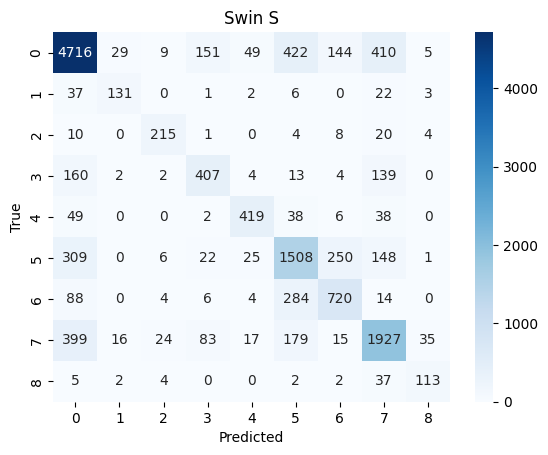

In [ ]:
all_preds = []
all_probs = []
all_y = []

for fold, (train_idx, test_idx) in enumerate(kfold.split(ds)):
    print(f"\nFold {fold + 1}:")

    test_ds = Subset(ds, test_idx)

    model = models.swin_s()
    model.head = nn.Linear(model.head.in_features, 9, bias=True)
    model.load_state_dict(torch.load(f"models/KFold/swin_s_atomic_fold{fold + 1}", weights_only=True))
    model.to(device);
    model.eval()

    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

    with torch.no_grad():
        for x, y in tqdm(test_loader):
            x, y = x.to(device), y.to(device).long()
            out = model(x)

            probs = torch.softmax(out, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())
            all_y.append(y.cpu())

all_probs = torch.cat(all_probs).numpy()
all_preds = torch.cat(all_preds).numpy().ravel()
all_y = torch.cat(all_y).numpy().ravel()

test_acc = accuracy_score(all_y, all_preds)
test_acc_binary = binary_accuracy(all_y, all_preds)
test_acc_light = light_accuracy(all_y, all_preds, [[5, 6], [5, 7]])
test_acc_confidence_90 = accuracy_when_confident(all_y, all_probs, 0.9)
test_acc_confidence_95 = accuracy_when_confident(all_y, all_probs, 0.95)
test_acc_confidence_99 = accuracy_when_confident(all_y, all_probs, 0.99)
conf_mat = confusion_matrix(all_y, all_preds)

print()
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test accuracy for 0 vs rest: {test_acc_binary:.4f}")
print(f"Test accuracy excluding 5=6 and 5=7 confusion: {test_acc_light:.4f}")
print(f"Test accuracy when 90% confident: {test_acc_confidence_90:.4f}")
print(f"Test accuracy when 95% confident: {test_acc_confidence_95:.4f}")
print(f"Test accuracy when 99% confident: {test_acc_confidence_99:.4f}")

sns.heatmap(conf_mat, cmap="Blues", annot=True, fmt="d")
plt.title("Swin S")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

#### ConvNeXt S


Fold 1:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:48<00:00,  1.11s/it]



Fold 2:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:48<00:00,  1.10s/it]



Fold 3:


...


Fold 4:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:48<00:00,  1.10s/it]



Fold 5:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:48<00:00,  1.10s/it]


Test accuracy: 0.7368
Test accuracy for 0 vs rest: 0.8368
Test accuracy excluding 5=6 and 5=7 confusion: 0.7935
Test accuracy when 90% confident: 0.8635
Test accuracy when 95% confident: 0.8936
Test accuracy when 99% confident: 0.9423


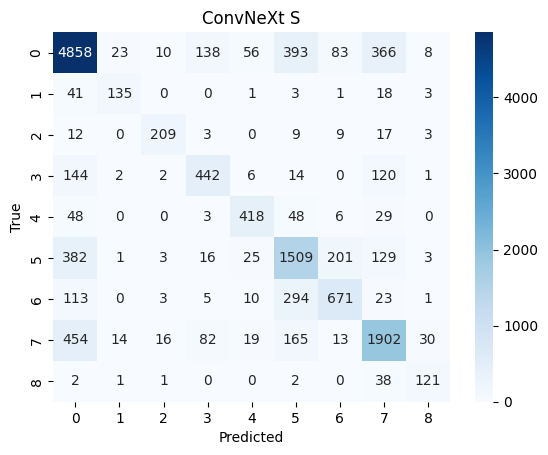

In [ ]:
all_preds = []
all_probs = []
all_y = []

for fold, (train_idx, test_idx) in enumerate(kfold.split(ds)):
    print(f"\nFold {fold + 1}:")

    test_ds = Subset(ds, test_idx)

    model = models.convnext_small()
    model.classifier[2] = nn.Linear(model.classifier[2].in_features, 9, bias=True)
    model.load_state_dict(torch.load(f"models/KFold/convnext_s_atomic_fold{fold + 1}", weights_only=True))
    model.to(device);
    model.eval()

    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

    with torch.no_grad():
        for x, y in tqdm(test_loader):
            x, y = x.to(device), y.to(device).long()
            out = model(x)

            probs = torch.softmax(out, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())
            all_y.append(y.cpu())

all_probs = torch.cat(all_probs).numpy()
all_preds = torch.cat(all_preds).numpy().ravel()
all_y = torch.cat(all_y).numpy().ravel()

test_acc = accuracy_score(all_y, all_preds)
test_acc_binary = binary_accuracy(all_y, all_preds)
test_acc_light = light_accuracy(all_y, all_preds, [[5, 6], [5, 7]])
test_acc_confidence_90 = accuracy_when_confident(all_y, all_probs, 0.9)
test_acc_confidence_95 = accuracy_when_confident(all_y, all_probs, 0.95)
test_acc_confidence_99 = accuracy_when_confident(all_y, all_probs, 0.99)
conf_mat = confusion_matrix(all_y, all_preds)

print()
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test accuracy for 0 vs rest: {test_acc_binary:.4f}")
print(f"Test accuracy excluding 5=6 and 5=7 confusion: {test_acc_light:.4f}")
print(f"Test accuracy when 90% confident: {test_acc_confidence_90:.4f}")
print(f"Test accuracy when 95% confident: {test_acc_confidence_95:.4f}")
print(f"Test accuracy when 99% confident: {test_acc_confidence_99:.4f}")

sns.heatmap(conf_mat, cmap="Blues", annot=True, fmt="d")
plt.title("ConvNeXt S")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

#### ResNet


Fold 1:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:37<00:00,  1.19it/s]



Fold 2:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:36<00:00,  1.19it/s]



Fold 3:


...


Fold 4:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:37<00:00,  1.17it/s]



Fold 5:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:36<00:00,  1.19it/s]


Test accuracy: 0.6991
Test accuracy for 0 vs rest: 0.8145
Test accuracy excluding 5=6 and 5=7 confusion: 0.7618
Test accuracy when 90% confident: 0.8480
Test accuracy when 95% confident: 0.8865
Test accuracy when 99% confident: 0.9383


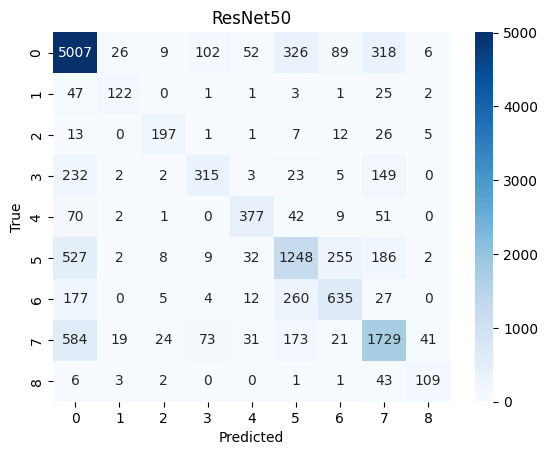

In [ ]:
all_preds = []
all_probs = []
all_y = []

for fold, (train_idx, test_idx) in enumerate(kfold.split(ds)):
    print(f"\nFold {fold + 1}:")

    test_ds = Subset(ds, test_idx)

    model = models.resnet50()
    model.fc = nn.Linear(model.fc.in_features, 9, bias=True)
    model.load_state_dict(torch.load(f"models/KFold/resnet50_atomic_fold{fold + 1}", weights_only=True))
    model.to(device);
    model.eval()

    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

    with torch.no_grad():
        for x, y in tqdm(test_loader):
            x, y = x.to(device), y.to(device).long()
            out = model(x)

            probs = torch.softmax(out, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())
            all_y.append(y.cpu())

all_probs = torch.cat(all_probs).numpy()
all_preds = torch.cat(all_preds).numpy().ravel()
all_y = torch.cat(all_y).numpy().ravel()

test_acc = accuracy_score(all_y, all_preds)
test_acc_binary = binary_accuracy(all_y, all_preds)
test_acc_light = light_accuracy(all_y, all_preds, [[5, 6], [5, 7]])
test_acc_confidence_90 = accuracy_when_confident(all_y, all_probs, 0.9)
test_acc_confidence_95 = accuracy_when_confident(all_y, all_probs, 0.95)
test_acc_confidence_99 = accuracy_when_confident(all_y, all_probs, 0.99)
conf_mat = confusion_matrix(all_y, all_preds)

print()
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test accuracy for 0 vs rest: {test_acc_binary:.4f}")
print(f"Test accuracy excluding 5=6 and 5=7 confusion: {test_acc_light:.4f}")
print(f"Test accuracy when 90% confident: {test_acc_confidence_90:.4f}")
print(f"Test accuracy when 95% confident: {test_acc_confidence_95:.4f}")
print(f"Test accuracy when 99% confident: {test_acc_confidence_99:.4f}")

sns.heatmap(conf_mat, cmap="Blues", annot=True, fmt="d")
plt.title("ResNet50")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

#### EfficientNet


Fold 1:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:40<00:00,  1.08it/s]



Fold 2:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:39<00:00,  1.11it/s]



Fold 3:


...


Fold 4:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:37<00:00,  1.17it/s]



Fold 5:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:37<00:00,  1.16it/s]



Test accuracy: 0.7021
Test accuracy for 0 vs rest: 0.8124
Test accuracy excluding 5=6 and 5=7 confusion: 0.7604
Test accuracy when 90% confident: 0.8408
Test accuracy when 95% confident: 0.8704
Test accuracy when 99% confident: 0.9317


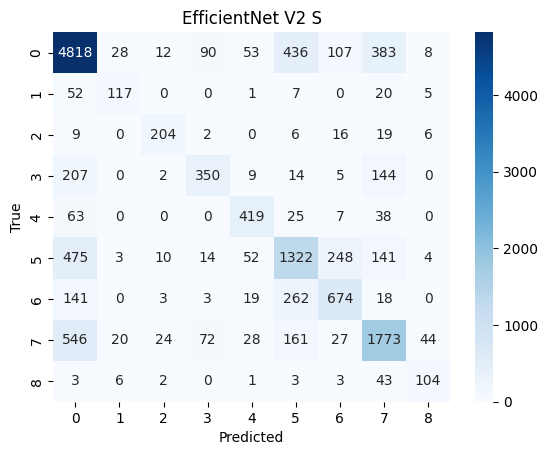

In [ ]:
all_preds = []
all_probs = []
all_y = []

for fold, (train_idx, test_idx) in enumerate(kfold.split(ds)):
    print(f"\nFold {fold + 1}:")

    test_ds = Subset(ds, test_idx)

    model = models.efficientnet_v2_s()
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 9, bias=True)
    model.load_state_dict(torch.load(f"models/KFold/efficientnet_v2_s_atomic_fold{fold + 1}", weights_only=True))
    model.to(device);
    model.eval()

    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

    with torch.no_grad():
        for x, y in tqdm(test_loader):
            x, y = x.to(device), y.to(device).long()
            out = model(x)

            probs = torch.softmax(out, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())
            all_y.append(y.cpu())

all_probs = torch.cat(all_probs).numpy()
all_preds = torch.cat(all_preds).numpy().ravel()
all_y = torch.cat(all_y).numpy().ravel()

test_acc = accuracy_score(all_y, all_preds)
test_acc_binary = binary_accuracy(all_y, all_preds)
test_acc_light = light_accuracy(all_y, all_preds, [[5, 6], [5, 7]])
test_acc_confidence_90 = accuracy_when_confident(all_y, all_probs, 0.9)
test_acc_confidence_95 = accuracy_when_confident(all_y, all_probs, 0.95)
test_acc_confidence_99 = accuracy_when_confident(all_y, all_probs, 0.99)
conf_mat = confusion_matrix(all_y, all_preds)

print()
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test accuracy for 0 vs rest: {test_acc_binary:.4f}")
print(f"Test accuracy excluding 5=6 and 5=7 confusion: {test_acc_light:.4f}")
print(f"Test accuracy when 90% confident: {test_acc_confidence_90:.4f}")
print(f"Test accuracy when 95% confident: {test_acc_confidence_95:.4f}")
print(f"Test accuracy when 99% confident: {test_acc_confidence_99:.4f}")

sns.heatmap(conf_mat, cmap="Blues", annot=True, fmt="d")
plt.title("EfficientNet V2 S")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

#### Другое

In [ ]:
def predict_image(model, image_path, transform, device):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = transform(image)

    image = image.unsqueeze(0)  # add batch dimension [1, C, H, W]
    image = image.to(device)

    with torch.no_grad():
        out = model(image)
        probs = torch.softmax(out, dim=1)
        preds = torch.argmax(probs, dim=1)

    return {
        "probability": probs.cpu().numpy(),
        "prediction": preds.cpu().numpy()
    }

In [ ]:
image_path = "data/test/photo_2026-03-06_16-35-59.jpg"
tr = Compose(
    [Resize((384, 384)), ToTensor(), Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]
)
predict_image(model, image_path, tr, device)

{'probability': array([[3.7496564e-01, 6.4114247e-05, 7.0584861e-06, 4.1219970e-04,
         1.9212954e-05, 4.0217450e-01, 2.2214401e-01, 2.0747725e-04,
         5.8436149e-06]], dtype=float32),
 'prediction': array([5], dtype=int64)}

Посмотрим, как модель ведёт себя на трейне


Fold 1:


100%|████████████████████████████████████████████████████████████████████████████████| 175/175 [03:40<00:00,  1.26s/it]



Fold 2:


100%|████████████████████████████████████████████████████████████████████████████████| 175/175 [04:04<00:00,  1.40s/it]



Fold 3:


...


Fold 4:


100%|████████████████████████████████████████████████████████████████████████████████| 175/175 [03:40<00:00,  1.26s/it]



Fold 5:


100%|████████████████████████████████████████████████████████████████████████████████| 175/175 [03:45<00:00,  1.29s/it]



Test accuracy: 0.9751
Test accuracy for 0 vs rest: 0.9864
Test accuracy excluding 5=6 and 5=7 confusion: 0.9829
Test accuracy when 90% confident: 0.9982
Test accuracy when 95% confident: 0.9992
Test accuracy when 99% confident: 0.9999


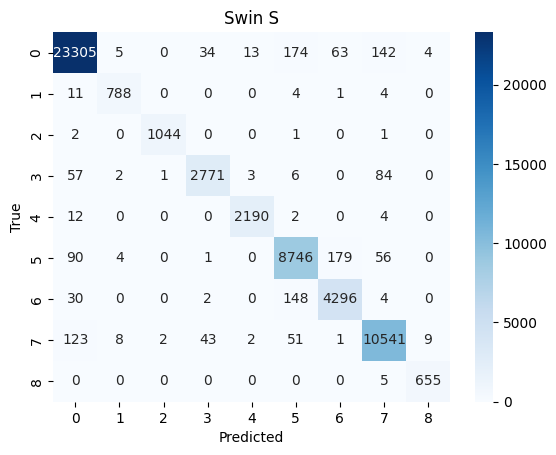

In [ ]:
all_preds = []
all_probs = []
all_y = []

for fold, (train_idx, test_idx) in enumerate(kfold.split(ds)):
    print(f"\nFold {fold + 1}:")

    test_ds = Subset(ds, train_idx)

    model = models.swin_s()
    model.head = nn.Linear(model.head.in_features, 9, bias=True)
    model.load_state_dict(torch.load(f"models/KFold/swin_s_atomic_fold{fold + 1}", weights_only=True))
    model.to(device);
    model.eval()

    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

    with torch.no_grad():
        for x, y in tqdm(test_loader):
            x, y = x.to(device), y.to(device).long()
            out = model(x)

            probs = torch.softmax(out, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())
            all_y.append(y.cpu())

all_probs = torch.cat(all_probs).numpy()
all_preds = torch.cat(all_preds).numpy().ravel()
all_y = torch.cat(all_y).numpy().ravel()

test_acc = accuracy_score(all_y, all_preds)
test_acc_binary = binary_accuracy(all_y, all_preds)
test_acc_light = light_accuracy(all_y, all_preds, [[5, 6], [5, 7]])
test_acc_confidence_90 = accuracy_when_confident(all_y, all_probs, 0.9)
test_acc_confidence_95 = accuracy_when_confident(all_y, all_probs, 0.95)
test_acc_confidence_99 = accuracy_when_confident(all_y, all_probs, 0.99)
conf_mat = confusion_matrix(all_y, all_preds)

print()
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test accuracy for 0 vs rest: {test_acc_binary:.4f}")
print(f"Test accuracy excluding 5=6 and 5=7 confusion: {test_acc_light:.4f}")
print(f"Test accuracy when 90% confident: {test_acc_confidence_90:.4f}")
print(f"Test accuracy when 95% confident: {test_acc_confidence_95:.4f}")
print(f"Test accuracy when 99% confident: {test_acc_confidence_99:.4f}")

sns.heatmap(conf_mat, cmap="Blues", annot=True, fmt="d")
plt.title("Swin S")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
len(np.unique(np.where((all_probs > 0.3) & ((all_probs < 0.6)))[0])) / len(all_probs)

0.04437944153327112

Посмотрим на датасет целиком


Noise:
Dataset loaded: 3340 images


100%|██████████████████████████████████████████████████████████████████████████████████| 53/53 [00:57<00:00,  1.09s/it]



Excluded data:
Dataset loaded: 3500 images


100%|██████████████████████████████████████████████████████████████████████████████████| 55/55 [01:13<00:00,  1.33s/it]



Fold 1:


...


Fold 4:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:50<00:00,  1.15s/it]



Fold 5:


100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:53<00:00,  1.20s/it]



Test accuracy: 0.7614
Test accuracy for 0 vs rest: 0.8710
Test accuracy excluding 5=6 and 5=7 confusion: 0.8372
Test accuracy when 90% confident: 0.8992
Test accuracy when 95% confident: 0.9270
Test accuracy when 99% confident: 0.9642


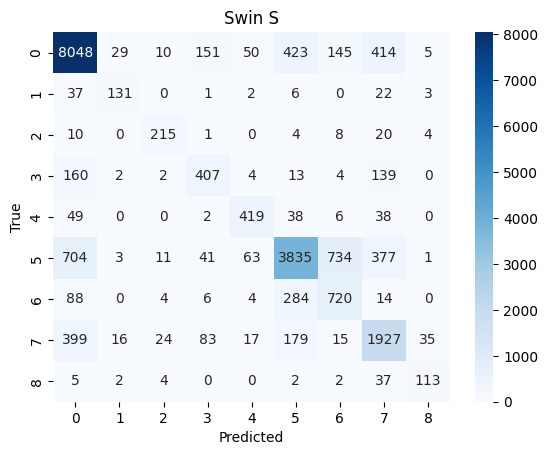

In [ ]:
all_preds = []
all_probs = []
all_y = []

model = models.swin_s()
model.head = nn.Linear(model.head.in_features, 9, bias=True)
model.load_state_dict(torch.load(f"models/KFold/swin_s_atomic_fold1", weights_only=True))
model.to(device);
model.eval()

# noise
print(f"\nNoise:")
csv_w_noise = "attr_classifier.csv"
noise_dir = "noise_images"
noise_ds = Attr(transform=default_transform, root_dir=root_dir, img_dir=noise_dir, csv_path=csv_w_noise)

test_loader = DataLoader(noise_ds, batch_size=64, shuffle=False)
with torch.no_grad():
    for x, y in tqdm(test_loader):
        x = x.to(device)
        out = model(x)
        probs = torch.softmax(out, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_y.append(torch.zeros(y.shape))


# excluded data
print(f"\nExcluded data:")
csv_excluded = "excluded_in_polished.csv"
excluded_ds = Attr(transform=default_transform, root_dir=root_dir, img_dir=img_dir, csv_path=csv_excluded)

test_loader = DataLoader(excluded_ds, batch_size=64, shuffle=False)
with torch.no_grad():
    for x, y in tqdm(test_loader):
        x, y = x.to(device), y.to(device).long()
        out = model(x)
        probs = torch.softmax(out, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_y.append(y.cpu())


# normal Kfold
for fold, (train_idx, test_idx) in enumerate(kfold.split(ds)):
    print(f"\nFold {fold + 1}:")

    test_ds = Subset(ds, test_idx)

    model = models.swin_s()
    model.head = nn.Linear(model.head.in_features, 9, bias=True)
    model.load_state_dict(torch.load(f"models/KFold/swin_s_atomic_fold{fold + 1}", weights_only=True))
    model.to(device);
    model.eval()

    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

    with torch.no_grad():
        for x, y in tqdm(test_loader):
            x, y = x.to(device), y.to(device).long()
            out = model(x)

            probs = torch.softmax(out, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())
            all_y.append(y.cpu())


all_probs = torch.cat(all_probs).numpy()
all_preds = torch.cat(all_preds).numpy().ravel()
all_y = torch.cat(all_y).numpy().ravel()

test_acc = accuracy_score(all_y, all_preds)
test_acc_binary = binary_accuracy(all_y, all_preds)
test_acc_light = light_accuracy(all_y, all_preds, [[5, 6], [5, 7]])
test_acc_confidence_90 = accuracy_when_confident(all_y, all_probs, 0.9)
test_acc_confidence_95 = accuracy_when_confident(all_y, all_probs, 0.95)
test_acc_confidence_99 = accuracy_when_confident(all_y, all_probs, 0.99)
conf_mat = confusion_matrix(all_y, all_preds)

print()
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test accuracy for 0 vs rest: {test_acc_binary:.4f}")
print(f"Test accuracy excluding 5=6 and 5=7 confusion: {test_acc_light:.4f}")
print(f"Test accuracy when 90% confident: {test_acc_confidence_90:.4f}")
print(f"Test accuracy when 95% confident: {test_acc_confidence_95:.4f}")
print(f"Test accuracy when 99% confident: {test_acc_confidence_99:.4f}")

sns.heatmap(conf_mat, cmap="Blues", annot=True, fmt="d")
plt.title("Swin S")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### Сохранение/Загрузка

Веса

In [ ]:
torch.save(model.state_dict(), "models/atomic_classifier/good_classes_swin_s.pth")

In [ ]:
model = models.convnext_small()
model.classifier[2] = nn.Linear(model.classifier[2].in_features, 9, bias=True)

model.load_state_dict(torch.load("models/KFold/convnext_s_atomic_fold1", weights_only=True))
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device);

In [ ]:
model = models.swin_s()
model.head = nn.Linear(model.head.in_features, 9, bias=True)
model.load_state_dict(torch.load("models/KFold/swin_s_atomic_fold1", weights_only=True))
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device);

In [ ]:
model = models.resnet50()
model.fc = nn.Linear(model.fc.in_features, 9, bias=True)
model.load_state_dict(torch.load("models/KFold/resnet50_atomic_fold1", weights_only=True))
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device);

Целиком

In [ ]:
model = models.efficientnet_v2_s()
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 9, bias=True)
model.load_state_dict(torch.load("models/KFold/efficientnet_v2_s_atomic_fold1", weights_only=True))
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device);

In [ ]:
scripted = torch.jit.script(model)

In [ ]:
scripted.save("models/atomic_classifier/good_classes_swin_s_scripted.pt")